In [11]:
from llg_emulator.data import LLGStepperSource
from llg_emulator.model import LLGEmulator
import jax.random as jr
from llg_emulator.metrics import rollout_trajectories
from pathlib import Path
import matplotlib.pyplot as plt
import jax.numpy as jnp

In [2]:
path = Path("../micromagnetic-data/data/dynamics/med/train")
source = LLGStepperSource(path=path)

100%|██████████| 3/3 [00:00<00:00, 114.53it/s]


In [3]:
key = jr.PRNGKey(0)
model = LLGEmulator(key=key)

In [8]:
m_true = jnp.stack(source.trajs, axis=0)
h_ext = jnp.stack(source.fields, axis=0)
m_pred = rollout_trajectories(m_true, h_ext, model)

In [ ]:
def correlation(pred, ref):
    # both shape (b, t, c, nx, ny)
    pointwise_correlation = jnp.sum(pred * ref, axis=-3)
    framewise_correlation = jnp.sqrt(jnp.mean(pointwise_correlation**2, axis=(-1, -2)))
    return framewise_correlation  # (b, t)

In [41]:
corrs = correlation(m_pred, m_true)
corrs.shape

(3, 101)

In [42]:
corrs

Array([[1.        , 0.9925447 , 0.96787524, 0.923321  , 0.85838354,
        0.7757088 , 0.68112797, 0.5828038 , 0.48991355, 0.41121793,
        0.3533897 , 0.31888708, 0.30464804, 0.3039209 , 0.3101041 ,
        0.31901476, 0.32886207, 0.3393074 , 0.35059404, 0.3630238 ,
        0.3767323 , 0.3916346 , 0.40743008, 0.42361397, 0.4394925 ,
        0.45421684, 0.46689892, 0.47684512, 0.48370585, 0.48742545,
        0.48816487, 0.48624006, 0.48204082, 0.47598526, 0.4685505 ,
        0.46031648, 0.45195454, 0.44415092, 0.43751684, 0.43252325,
        0.4294717 , 0.42848358, 0.4295018 , 0.43233073, 0.43669915,
        0.44223896, 0.44839755, 0.454546  , 0.4602454 , 0.46531832,
        0.46969825, 0.4733857 , 0.47671774, 0.47998208, 0.48282003,
        0.48506   , 0.48698008, 0.48891208, 0.49144417, 0.49520117,
        0.50011307, 0.5052611 , 0.5096249 , 0.5128072 , 0.5151674 ,
        0.5176275 , 0.5210591 , 0.52577996, 0.53127646, 0.53618014,
        0.53941005, 0.54108995, 0.54214644, 0.54

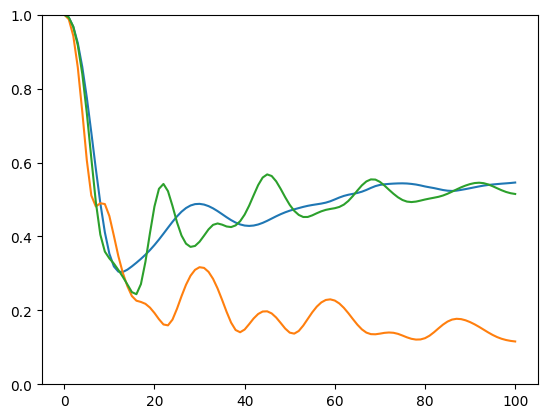

In [43]:
for c in corrs:
    plt.plot(c)
plt.ylim((0, 1))
plt.show()